--- 
#### 5-1. ML실습_회귀2
- Car Price prediction 
--- 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

In [2]:
# data loading
df = pd.read_csv('data/car_price_prediction.csv')

print(df.shape)
display(df.head())

(19237, 18)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [3]:
# 변수타입 확인 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [4]:
# 범주형 변수들의 구성 확인 
cat_cols = df.select_dtypes(include='object').columns
i = cat_cols.values
print('범주형 변수 : ', i)

j = 1
df[cat_cols[j]].unique()

범주형 변수 :  ['Levy' 'Manufacturer' 'Model' 'Category' 'Leather interior' 'Fuel type'
 'Engine volume' 'Mileage' 'Gear box type' 'Drive wheels' 'Doors' 'Wheel'
 'Color']


array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFA ROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ',
       'CITROEN', 'LAND ROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR',
       'ISUZU', 'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC',
       'PEUGEOT', 'BENTLEY', 'VOLVO', 'სხვა', 'HAVAL', 'HUMMER', 'SCION',
       'UAZ', 'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL'], dtype=object)

In [5]:
# 결측치 확인 
print(df.isnull().sum())

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64


count       19,237.00
mean        18,555.93
std        190,581.27
min              1.00
25%          5,331.00
50%         13,172.00
75%         22,075.00
max     26,307,500.00
Name: Price, dtype: float64


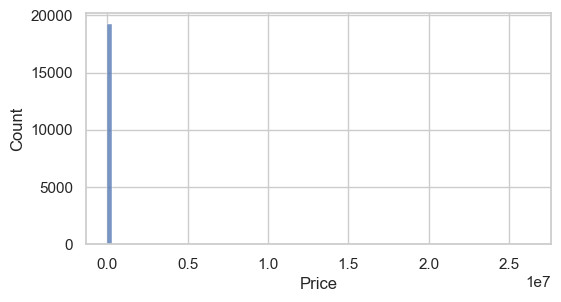

In [6]:
# target 분포 확인 
pd.options.display.float_format = '{:,.2f}'.format  ## 지수표기법 -> 실수표기로 변경 
print(df['Price'].describe())

plt.figure(figsize=(6,3))
sns.histplot(df['Price'], bins=100)
plt.show()

- 결측치는 없다. 
- Levy는 보기에 숫자이나, 문자열로 기록됨 
- Engine volume은 '숫자'만 또는 '숫자+turbo'가 혼재 
- Mileage는 '숫자+단위(km)'가 혼재 
- Doors(문의 개수)가 이상하게 기록되어 있다. ('04-May', '02-Mar', '>5')
- 제조사, 특히 모델은 종류가 너무나 많다. 
  
- 타겟인 Price가 극단적으로 치우친 분포이다. 

#### [실무자로 부터 얻은 정보]
- 입고되어 아직 가격산정이 되지 않은 경우 0,1,9999 등 의미없는 값을 일단 기입하는 경우가 있다. 
- 정상 거래가 아닌, 폐차 또는 부품 활용을 위해 구입한 건도 일부 포함되어 있다. 
- 초고가의 슈퍼카, 클래식카는 가격 예측이 무의미하다. 
- 여기서는 1000 ~ 50000 달러 까지를 정상적인 가격범위로 간주한다. 
---

In [7]:
# price가 정상인 데이터만 추출 
df = df[
    (df['Price'] >= 1000) & (df['Price'] <= 50000)
]

df.shape

(15740, 18)

In [8]:
##################################################################
# 범주형 레이블 인코딩 (모델의 경우 One-Hot 인코딩 하기에는 개수가 너무 많다.)
##################################################################
from sklearn.preprocessing import LabelEncoder 

for col in cat_cols: 
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head()    

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,107,29,1160,2010,4,1,2,62,2453,6.00,0,0,1,0,12,12
1,44731507,16621,4,6,619,2011,4,0,5,55,2555,6.00,2,0,1,0,1,8
2,45774419,8467,0,19,644,2006,3,0,5,21,2705,4.00,3,1,1,1,1,2
3,45769185,3607,472,14,622,2011,4,1,2,45,2101,4.00,0,0,1,0,14,0
4,45809263,11726,332,19,644,2014,3,1,5,21,6230,4.00,0,1,1,0,12,4


In [9]:
##################################################################
# 1. Feature Engineering 없이 모델링 
##################################################################
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score 

y = df['Price']
X = df.drop('Price', axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)  # 회귀문제에서는 y가 연속형이므로 stratify 옵션을 쓸 수 없다. 

rf = RandomForestRegressor(random_state=120)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)
rmse = root_mean_squared_error(y_valid, rf_pred)
r2 = r2_score(y_valid, rf_pred)

print('RMSE  = ', round(rmse,4))
print('R2  = ', round(r2,4)) 

RMSE  =  4990.6182
R2  =  0.8038


In [10]:
##################################################################
# 2. Feature Engineering 추가 
# Levy, Engine volume, Mileage, Doors  
##################################################################

df = pd.read_csv('data/car_price_prediction.csv')
# price가 정상인 데이터만 추출 
df = df[
    (df['Price'] >= 1000) & (df['Price'] <= 50000)
]

## Levy : '-'를 결측치 처리 > 수치형으로 변환 > 결측치 평균 대체 
df['Levy'] = df['Levy'].replace('-', np.nan)
df['Levy'] = df['Levy'].astype(float)
df['Levy'] = df['Levy'].fillna(df['Levy'].mean())

## Engine volume : 터보 여부 구분 컬럼 별도 생성, 배기량은 숫자만 
df['Turbo'] = df['Engine volume'].str.contains('Turbo').astype(float)
df['Engine volume'] = df['Engine volume'].str.replace('Turbo', '').astype(float)

## Mileage : km 제거하고 수치형으로 변환 
df['Mileage'] = df['Mileage'].str.split().str[0].astype(float)

## Doors : 2, 4, 5+ 로 변환 
df['Doors'] = df['Doors'].replace({
    '02-Mar' : '2', 
    '04-May' : '4', 
    '>5' : '5+' 
})

## 범주형 인코딩 
cat_cols = df.select_dtypes(include='object')

for col in cat_cols: 
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    
df2 = df.copy() 
df2.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Turbo
0,45654403,13328,"1,399.00",29,1160,2010,4,1,2,3.50,"186,005.00",6.00,0,0,1,0,12,12,0.00
1,44731507,16621,"1,018.00",6,619,2011,4,0,5,3.00,"192,000.00",6.00,2,0,1,0,1,8,0.00
2,45774419,8467,875.12,19,644,2006,3,0,5,1.30,"200,000.00",4.00,3,1,1,1,1,2,0.00
3,45769185,3607,862.00,14,622,2011,4,1,2,2.50,"168,966.00",4.00,0,0,1,0,14,0,0.00
4,45809263,11726,446.00,19,644,2014,3,1,5,1.30,"91,901.00",4.00,0,1,1,0,12,4,0.00


In [11]:
y = df2['Price']
X = df2.drop('Price', axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)  

rf = RandomForestRegressor(random_state=120)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)
rmse = root_mean_squared_error(y_valid, rf_pred)
r2 = r2_score(y_valid, rf_pred)

print('RMSE with F/E = ', round(rmse,4))
print('R2 with F/E = ', round(r2,4)) 

RMSE with F/E =  4932.0504
R2 with F/E =  0.8084


In [12]:
##################################################################
# 3. 파생변수 추가 
# 연식대비 주행거리, 브랜드 프리미엄, 엔진x터보
##################################################################

df = pd.read_csv('data/car_price_prediction.csv')
# price가 정상인 데이터만 추출 
df = df[
    (df['Price'] >= 1000) & (df['Price'] <= 50000)
]

## Levy : '-'를 결측치 처리 > 수치형으로 변환 > 결측치 평균 대체 
df['Levy'] = df['Levy'].replace('-', np.nan)
df['Levy'] = df['Levy'].astype(float)
df['Levy'] = df['Levy'].fillna(df['Levy'].mean())

## Engine volume : 터보 여부 구분 컬럼 별도 생성, 배기량은 숫자만 
df['Turbo'] = df['Engine volume'].str.contains('Turbo').astype(float)
df['Engine volume'] = df['Engine volume'].str.replace('Turbo', '').astype(float)

## Mileage : km 제거하고 수치형으로 변환 
df['Mileage'] = df['Mileage'].str.split().str[0].astype(float)

## Doors : 2, 4, 5+ 로 변환 
df['Doors'] = df['Doors'].replace({
    '02-Mar' : '2', 
    '04-May' : '4', 
    '>5' : '5+' 
})

# 연식대비 주행거리 (데이터 기준연도는 22년)
df['Car_age'] = 2022 - df['Prod. year']
df['Mileage_per_year'] = df['Mileage'] / df['Car_age']

# 엔진 배기량 x 터보 
df['Turbo_premium'] = df['Engine volume'] * df['Turbo']

# 제조사(브랜드) 프리미엄
global_mean = df['Price'].mean()
brand_mean = df.groupby('Manufacturer')['Price'].transform('mean')
df['Brand_price'] = brand_mean.fillna(global_mean)

df['Brand_Engine'] = df['Brand_price'] * df['Engine volume']
df['Brand_Age'] = df['Brand_price'] * df['Car_age']

## 범주형 인코딩 
cat_cols = df.select_dtypes(include='object')

for col in cat_cols: 
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,...,Wheel,Color,Airbags,Turbo,Car_age,Mileage_per_year,Turbo_premium,Brand_price,Brand_Engine,Brand_Age
0,45654403,13328,"1,399.00",29,1160,2010,4,1,2,3.50,...,0,12,12,0.00,12,"15,500.42",0.00,"19,283.16","67,491.05","231,397.90"
1,44731507,16621,"1,018.00",6,619,2011,4,0,5,3.00,...,0,1,8,0.00,11,"17,454.55",0.00,"15,584.07","46,752.21","171,424.77"
2,45774419,8467,875.12,19,644,2006,3,0,5,1.30,...,1,1,2,0.00,16,"12,500.00",0.00,"13,838.91","17,990.58","221,422.51"
3,45769185,3607,862.00,14,622,2011,4,1,2,2.50,...,0,14,0,0.00,11,"15,360.55",0.00,"14,570.53","36,426.32","160,275.81"
4,45809263,11726,446.00,19,644,2014,3,1,5,1.30,...,0,12,4,0.00,8,"11,487.62",0.00,"13,838.91","17,990.58","110,711.26"


In [13]:
y = df['Price']
X = df.drop('Price', axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)  

rf = RandomForestRegressor(random_state=120)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)
rmse = root_mean_squared_error(y_valid, rf_pred)
r2 = r2_score(y_valid, rf_pred)

print('RMSE with add_vars = ', round(rmse,4))
print('R2 with add_vars = ', round(r2,4)) 

RMSE with add_vars =  4860.2708
R2 with add_vars =  0.8139
